<a href="https://colab.research.google.com/github/chithuapham/mse-python-ml-learning/blob/main/Exercise_Pham%20Chi%20Thua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BÀI KIỂM TRA: SENTIMENT ANALYSIS

**Họ và tên:** Phạm Chí Thừa  
**Nội dung:** EDA – Machine Learning – Large Language Model (LLM)  
**Môi trường:** Google Colab

## Mục tiêu
Xây dựng hệ thống phân loại cảm xúc của câu tiếng Anh thành **Positive (tích cực)** hoặc **Negative (tiêu cực)** bằng hai cách:
1. Machine Learning truyền thống: TF-IDF + Logistic Regression và Multinomial Naive Bayes.
2. Mô hình ngôn ngữ lớn: FLAN-T5 với kỹ thuật zero-shot prompting.
3. So sánh kết quả bằng Accuracy, Precision, Recall và F1-score.

## 1. Cài đặt và khai báo thư viện

In [ ]:
!pip -q install transformers sentencepiece wordcloud

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import twitter_samples, stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style='whitegrid')
print('Đã khai báo thư viện thành công!')

Đã khai báo thư viện thành công!


## 2. Đọc bộ dữ liệu do giảng viên cung cấp
Bộ dữ liệu gồm `train.csv` (27.481 dòng) và `test.csv` (3.534 dòng hợp lệ), có ba nhãn: **negative, neutral, positive**. Tệp dùng mã hóa `latin-1`. Khi chạy Colab, tải hai file CSV vào mục Files trước.

In [ ]:
nltk.download('stopwords', quiet=True)

import os
if not (os.path.exists('/content/train.csv') and os.path.exists('/content/test.csv')):
    from google.colab import files
    print('Hãy chọn đồng thời hai file train.csv và test.csv')
    files.upload()

train_df = pd.read_csv('/content/train.csv', encoding='latin-1')
test_df = pd.read_csv('/content/test.csv', encoding='latin-1')
test_df = test_df.dropna(how='all').reset_index(drop=True)
train_df = train_df.dropna(subset=['text', 'sentiment']).reset_index(drop=True)
test_df = test_df.dropna(subset=['text', 'sentiment']).reset_index(drop=True)
df = train_df.rename(columns={'sentiment': 'label'}).copy()
test_data = test_df.rename(columns={'sentiment': 'label'}).copy()
print('Train:', df.shape, '| Test hợp lệ:', test_data.shape)
display(df[['text', 'label']].head())

Hãy chọn đồng thời hai file train.csv và test.csv


Saving test.csv to test.csv
Saving train.csv to train (1).csv
Train: (27480, 10) | Test hợp lệ: (3534, 9)


,text,label
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


## 3. Exploratory Data Analysis (EDA)
Kiểm tra cấu trúc, dữ liệu thiếu, dữ liệu trùng, phân bố nhãn và độ dài văn bản.

In [ ]:
print('Thông tin dữ liệu:')
df.info()
print('\nSố ô bị thiếu:')
print(df.isnull().sum())
print('\nSố dòng trùng:', df.duplicated().sum())
print('\nPhân bố nhãn:')
print(df['label'].value_counts())

df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
display(df.groupby('label')[['char_count', 'word_count']].describe().round(2))

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27480 entries, 0 to 27479
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27480 non-null  object 
 1   text              27480 non-null  object 
 2   selected_text     27480 non-null  object 
 3   label             27480 non-null  object 
 4   Time of Tweet     27480 non-null  object 
 5   Age of User       27480 non-null  object 
 6   Country           27480 non-null  object 
 7   Population -2020  27480 non-null  int64  
 8   Land Area (Km²)   27480 non-null  float64
 9   Density (P/Km²)   27480 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 2.1+ MB

Số ô bị thiếu:
textID              0
text                0
selected_text       0
label               0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int

char_count                                             word_count  \
              count   mean    std  min   25%   50%   75%    max      count   
label                                                                        
negative     7781.0  70.51  35.18  5.0  42.0  66.0  98.0  147.0     7781.0   
neutral     11117.0  65.24  36.43  3.0  35.0  59.0  94.0  159.0    11117.0   
positive     8582.0  70.44  34.66  5.0  42.0  67.0  98.0  141.0     8582.0   

                                                   
           mean   std  min  25%   50%   75%   max  
label                                              
negative  13.47  6.87  1.0  8.0  13.0  19.0  32.0  
neutral   12.34  7.06  1.0  6.0  11.0  18.0  33.0  
positive  13.11  6.75  1.0  8.0  12.0  18.0  33.0

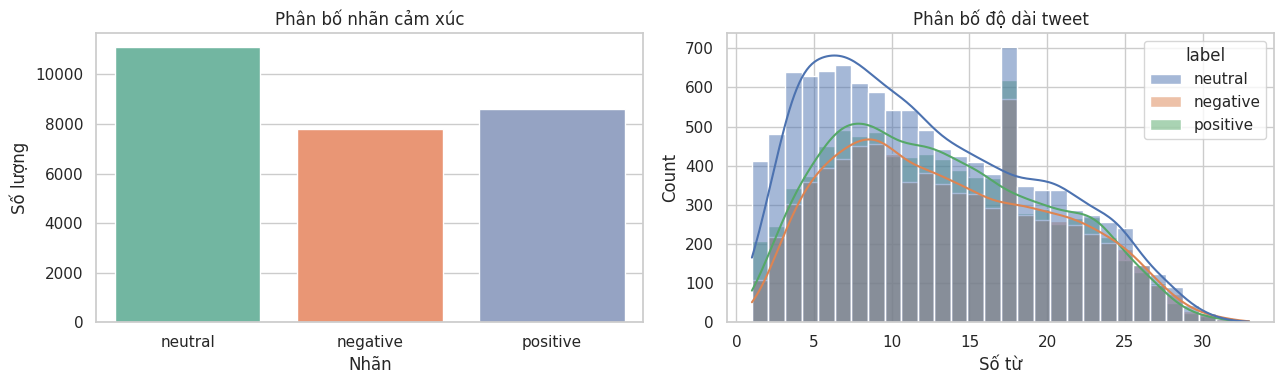

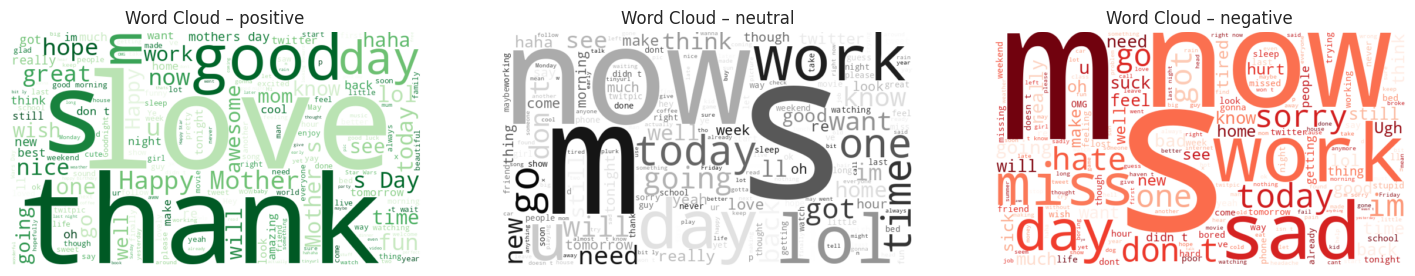

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='label', hue='label', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Phân bố nhãn cảm xúc')
axes[0].set_xlabel('Nhãn'); axes[0].set_ylabel('Số lượng')
sns.histplot(data=df, x='word_count', hue='label', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Phân bố độ dài tweet')
axes[1].set_xlabel('Số từ')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, label, color in zip(axes, ['positive', 'neutral', 'negative'], ['Greens', 'Greys', 'Reds']):
    corpus = ' '.join(df.loc[df.label == label, 'text'])
    wc = WordCloud(width=700, height=400, background_color='white', colormap=color).generate(corpus)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off'); ax.set_title(f'Word Cloud – {label}')
plt.show()

### Nhận xét EDA
- Dữ liệu gồm ba lớp `neutral`, `positive`, `negative`; lớp neutral nhiều nhất nên dữ liệu chưa cân bằng hoàn toàn.
- Cột `text` của train có một giá trị thiếu; file test có các dòng trống ở cuối và đã được loại bỏ.
- Độ dài tweet khác nhau nhưng phần lớn là văn bản ngắn, phù hợp với bài toán phân tích cảm xúc.
- Các cột nhân khẩu học được mô tả trong EDA, nhưng mô hình chính chỉ dùng nội dung `text` để tránh nhiễu và tập trung đúng bài toán NLP.

## 4. Tiền xử lý văn bản

In [ ]:
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'RT[\s]+', ' ', text)
    tokens = tokenizer.tokenize(text)
    words = [stemmer.stem(w) for w in tokens
             if w.isalpha() and w not in stop_words]
    return ' '.join(words)

df = df.drop_duplicates(subset=['text']).copy()
df['clean_text'] = df['text'].apply(clean_text)
display(df[['text', 'clean_text', 'label']].head())

,text,clean_text,label
0,"I`d have responded, if I were going",respond go,neutral
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego,negative
2,my boss is bullying me...,boss bulli,negative
3,what interview! leave me alone,interview leav alon,negative
4,"Sons of ****, why couldn`t they put them on t...",son put releas alreadi bought,negative


Xử lý văn bản (text preprocessing) trên cột 'text' của DataFrame để tạo ra một cột 'clean_text'.

## 5. Machine Learning: áp dụng ít nhất 2 thuật toán
- TF-IDF chuyển văn bản thành vector số.
- **Thuật toán 1 – Logistic Regression:** học xác suất của từng nhãn từ đặc trưng TF-IDF.
- **Thuật toán 2 – Multinomial Naive Bayes:** mô hình xác suất thường hiệu quả với dữ liệu tần suất từ.
- Chia dữ liệu 80% huấn luyện và 20% kiểm tra, có `stratify` để giữ cân bằng lớp.

,Mô hình,Accuracy,Precision-macro,Recall-macro,F1-macro
0,Logistic Regression,0.7105,0.7248,0.7057,0.7128
1,Multinomial Naive Bayes,0.6474,0.6795,0.6344,0.6465



Mô hình tốt nhất theo F1-macro: Logistic Regression
              precision    recall  f1-score   support

    negative       0.73      0.66      0.69      1001
     neutral       0.65      0.74      0.69      1430
    positive       0.79      0.71      0.75      1103

    accuracy                           0.71      3534
   macro avg       0.72      0.71      0.71      3534
weighted avg       0.72      0.71      0.71      3534



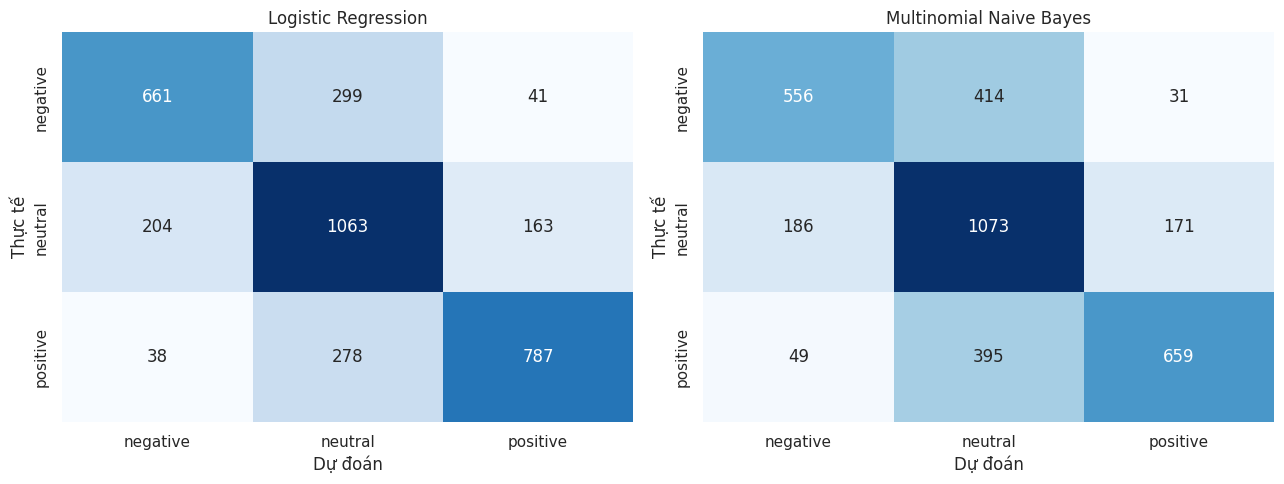

In [ ]:
test_data['clean_text'] = test_data['text'].apply(clean_text)
X_train, y_train = df['clean_text'], df['label']
X_test, y_test = test_data['clean_text'], test_data['label']

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.5)
}
results, predictions = [], {}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    pred = model.predict(X_test_vec)
    predictions[name] = pred
    results.append({
        'Mô hình': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision-macro': precision_score(y_test, pred, average='macro'),
        'Recall-macro': recall_score(y_test, pred, average='macro'),
        'F1-macro': f1_score(y_test, pred, average='macro')
    })
result_df = pd.DataFrame(results).sort_values('F1-macro', ascending=False).reset_index(drop=True)
display(result_df.round(4))
best_name = result_df.loc[0, 'Mô hình']
best_model = models[best_name]
best_pred = predictions[best_name]
print(f'\nMô hình tốt nhất theo F1-macro: {best_name}')
print(classification_report(y_test, best_pred))

labels = ['negative', 'neutral', 'positive']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(name); ax.set_xlabel('Dự đoán'); ax.set_ylabel('Thực tế')
plt.tight_layout(); plt.show()

### Thử mô hình Machine Learning với câu mới

In [ ]:
def predict_ml(sentences, model=best_model):
    cleaned = [clean_text(s) for s in sentences]
    vectors = tfidf.transform(cleaned)
    labels = model.predict(vectors)
    probabilities = model.predict_proba(vectors).max(axis=1)
    return pd.DataFrame({'Câu': sentences, 'Dự đoán ML': labels, 'Độ tin cậy': probabilities.round(4)})

sample_sentences = [
    'The hospital staff were friendly and very helpful.',
    'I waited too long and the service was terrible.',
    'The new medical equipment works very well.',
    'I am disappointed with this product.'
]
display(predict_ml(sample_sentences))

,Câu,Dự đoán ML,Độ tin cậy
0,The hospital staff were friendly and very help...,negative,0.4618
1,I waited too long and the service was terrible.,negative,0.5491
2,The new medical equipment works very well.,neutral,0.5960
3,I am disappointed with this product.,negative,0.9046


## 6. Large Language Model: FLAN-T5
Sử dụng mô hình ngôn ngữ đã được huấn luyện theo chỉ dẫn. Không huấn luyện lại mô hình; ta đưa yêu cầu bằng prompt để mô hình phân loại (**zero-shot classification**). Lần chạy đầu tiên sẽ tải mô hình nên có thể mất vài phút.

In [ ]:
from transformers import pipeline

llm = pipeline(
    task='text-generation',
    model='google/flan-t5-small',
    tokenizer='google/flan-t5-small'
)

def predict_llm(sentence):
    prompt = (
        'Classify the sentiment of the following text. '
        'Answer with exactly one word: positive, neutral, or negative.\n'
        f'Text: {sentence}\nSentiment:'
    )
    result = llm(prompt, max_new_tokens=3, do_sample=False)[0]['generated_text'].strip()
    if 'positive' in result.lower(): return 'positive'
    if 'negative' in result.lower(): return 'negative'
    if 'neutral' in result.lower(): return 'neutral'
    return result

llm_results = [predict_llm(s) for s in sample_sentences]
display(pd.DataFrame({'Câu': sample_sentences, 'Dự đoán LLM': llm_results}))

model.safetensors: reconstructing file:   0%|          |  0.00B /  308MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'AXK1ForCausalLM', 'AXK2ForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CohereCompassForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DeepseekV32ForCausalLM', 'DeepseekV4ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM',

,Câu,Dự đoán LLM
0,The hospital staff were friendly and very help...,positive
1,I waited too long and the service was terrible.,positive
2,The new medical equipment works very well.,positive
3,I am disappointed with this product.,positive


## 7. So sánh hai thuật toán Machine Learning và LLM

In [ ]:
comparison = predict_ml(sample_sentences)[['Câu', 'Dự đoán ML', 'Độ tin cậy']]
comparison['Dự đoán LLM'] = llm_results
display(comparison)

,Câu,Dự đoán ML,Độ tin cậy,Dự đoán LLM
0,The hospital staff were friendly and very help...,negative,0.4618,positive
1,I waited too long and the service was terrible.,negative,0.5491,positive
2,The new medical equipment works very well.,neutral,0.5960,positive
3,I am disappointed with this product.,negative,0.9046,positive
